In [ ]:
**** Questão 02 ****

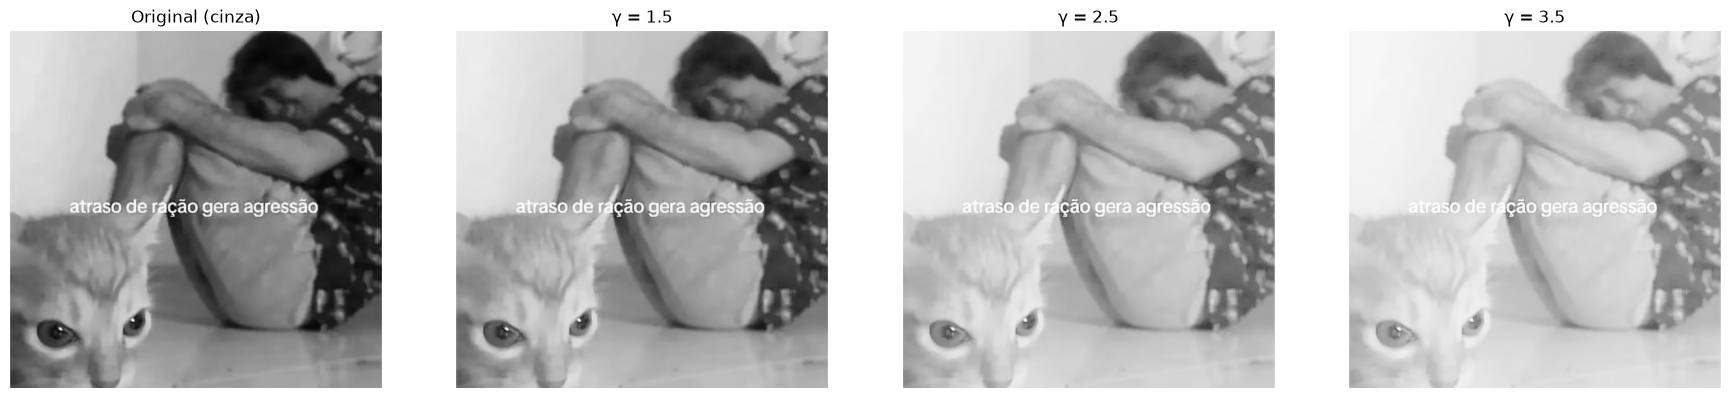

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Carregamento (permitido pelas regras)
imagem_bgr = cv2.imread('cat1.jpeg')
if imagem_bgr is None:
    raise FileNotFoundError("Não achei a imagem, confere o nome e a pasta")

# Conversão manual para tons de cinza (luminância)
canal_azul = imagem_bgr[:, :, 0]
canal_verde = imagem_bgr[:, :, 1]
canal_vermelho = imagem_bgr[:, :, 2]
imagem_cinza = 0.299 * canal_vermelho + 0.587 * canal_verde + 0.114 * canal_azul


def correcao_gama_manual(imagem_entrada, valor_gama):
    # (i) [0, 255] -> [0, 1]
    imagem_normalizada = imagem_entrada / 255.0
    # (ii) B = A^(1/gama)
    imagem_corrigida = imagem_normalizada ** (1.0 / valor_gama)
    # (iii) [0, 1] -> [0, 255]
    return np.clip(np.round(imagem_corrigida * 255.0), 0, 255).astype(np.uint8)


lista_gamas = [ 1.5, 2.5, 3.5]
resultados = {gama: correcao_gama_manual(imagem_cinza, gama) for gama in lista_gamas}

# Comparação visual com escala fixa
plt.figure(figsize=(18, 4))
plt.subplot(1, len(lista_gamas) + 1, 1)
plt.imshow(imagem_cinza, cmap='gray', vmin=0, vmax=255)
plt.title('Original (cinza)')
plt.axis('off')

for posicao, gama in enumerate(lista_gamas, start=2):
    plt.subplot(1, len(lista_gamas) + 1, posicao)
    plt.imshow(resultados[gama], cmap='gray', vmin=0, vmax=255)
    plt.title(f'γ = {gama}')
    plt.axis('off')

plt.tight_layout()
plt.savefig('comparacao_gama.png', dpi=150)  # pra colocar no PDF
plt.show()

In [ ]:
**** Questão 04 ****